# Disneyland Reviews — Supervised Baselines

**Team 4 — Sentiment Analysis (NLP).** Machine Learning 2026-III.

Workshop #1 deliverable: baseline classifiers on the engineered features. This
notebook *presents* the results — all training lives in `src/baselines.py`, so the
numbers here are reproducible from the command line (`python -m src.baselines`).

Evaluation is on the **validation** split; the test split is kept untouched for the
final comparison in later workshops.

## 1. Imports and training

`run()` trains the baselines once and returns their metrics plus confusion
matrices. Nothing is re-trained in this notebook.

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

from src.baselines import run
from src import plots

plots.apply_theme()
results = run()  # trains Majority + Logistic Regression, evaluates on validation


Baseline 0 - Majority class
accuracy : 0.7953
macro-F1 : 0.2953  <- headline metric

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       543
     neutral       0.00      0.00      0.00       766
    positive       0.80      1.00      0.89      5086

    accuracy                           0.80      6395
   macro avg       0.27      0.33      0.30      6395
weighted avg       0.63      0.80      0.70      6395

confusion matrix (rows = true, cols = predicted):
              negative   neutral  positive
  negative           0         0       543
   neutral           0         0       766
  positive           0         0     5,086


c:\Users\Andro\AppData\Local\pypoetry\Cache\virtualenvs\ml-npl-5WV0705R-py3.12\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Baseline 1 - Logistic Regression
accuracy : 0.7839
macro-F1 : 0.6257  <- headline metric

              precision    recall  f1-score   support

    negative       0.52      0.71      0.60       543
     neutral       0.32      0.50      0.39       766
    positive       0.95      0.83      0.89      5086

    accuracy                           0.78      6395
   macro avg       0.60      0.68      0.63      6395
weighted avg       0.84      0.78      0.81      6395

confusion matrix (rows = true, cols = predicted):
              negative   neutral  positive
  negative         387       125        31
   neutral         214       380       172
  positive         147       693     4,246

Baseline 2 - Random Forest
accuracy : 0.8227
macro-F1 : 0.4630  <- headline metric

              precision    recall  f1-score   support

    negative       0.66      0.34      0.45       543
     neutral       0.48      0.02      0.03       766
    positive       0.83      1.00      0.91      5086

   

## 2. Comparison

The headline metric is **macro-F1**, not accuracy — with 79.5% of reviews positive,
accuracy rewards a model that ignores the minority classes.

In [15]:
table = pd.DataFrame(
    [{'model': r['model'], 'accuracy': r['accuracy'], 'macro_f1': r['macro_f1']}
     for r in results]
).set_index('model').sort_values('macro_f1', ascending=False)
table.round(4)

,accuracy,macro_f1
model,,
Baseline 1 - Logistic Regression,0.7839,0.6257
Baseline 2 - Random Forest,0.8227,0.4630
Baseline 0 - Majority class,0.7953,0.2953


Read these two columns together. The majority-class baseline **it´s better on accuracy**
yet collapses on macro-F1 — it never predicts a negative or neutral review. Logistic
Regression gives up a little accuracy to more than double macro-F1, which is exactly
the trade a sentiment model should make.
Random Forest **overcome in accuaracy** and have a better performance in macro_f1.

## 3. Confusion matrices

Rows are the true class, columns the prediction. Shading is normalised per row, so
colour reads as recall; the numbers are raw counts.

C:\Users\Andro\Documents\UD\2026-3\Machine_Learning\ML-NLP-Sentimental-Analysis\ML_NPL\src\plots.py:316: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  shade = np.divide(matrix, row_totals, where=row_totals != 0)
C:\Users\Andro\Documents\UD\2026-3\Machine_Learning\ML-NLP-Sentimental-Analysis\ML_NPL\src\plots.py:316: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  shade = np.divide(matrix, row_totals, where=row_totals != 0)
C:\Users\Andro\Documents\UD\2026-3\Machine_Learning\ML-NLP-Sentimental-Analysis\ML_NPL\src\plots.py:316: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  shade = np.divide(matrix, row_totals, where=row_totals != 0)


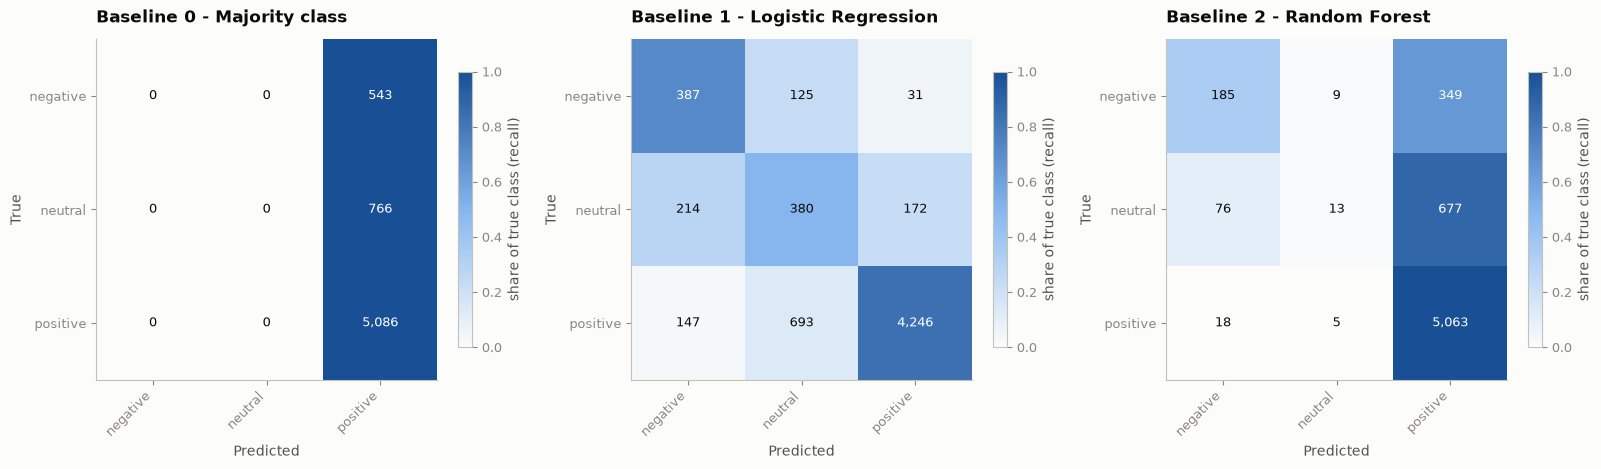

In [16]:
fig, axes = plt.subplots(1, len(results), figsize=(5.4 * len(results), 4.4))
if len(results) == 1:
    axes = [axes]
for ax, r in zip(axes, results):
    plots.confusion_heatmap(r['confusion'], r['labels'],
                            title=r['model'], ax=ax)
plt.tight_layout(); plt.show()

## 4. Reading the results

* **Majority baseline** — the floor: ~79.5% accuracy, macro-F1 ~0.30. Its confusion
  matrix is a single lit column: every review is called positive.
* **Logistic Regression** — recovers the minority classes (negative recall ~0.71,
  neutral ~0.49) thanks to balanced class weights, at the cost of a little accuracy.
* ***Random Forest* - The Random Forest almost ignores the neutral class(neutral recall ~0.02), absorbing it into the positive majority and few of negatives(negative recall ~ 0,34 the half of the logistic regrresor)
Next baselines ( Naive Bayes) slot into `src/baselines.py` through the
same `evaluate` helper and will appear in the table and the matrices automatically.